# Llama-3.1-70B


In [1]:
import json
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
import numpy as np

# Set hatch linewidth to make patterns more visible
mpl.rcParams['hatch.linewidth'] = 2.0

# Font size control
FONTSIZE = 28

# System colors and hatches (consistent across all figures)
SYSTEM_STYLE = {
    'ShuntServe': {'color': '#3498db', 'hatch': '/'},
    'HexGen':     {'color': '#1abc9c', 'hatch': '\\'},
    'AlpaServe':  {'color': '#e91e63', 'hatch': 'x'},
    'vLLM':       {'color': '#9b59b6', 'hatch': '+'},
}

BASE_DIR = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else '.'
RESULTS_DIR = os.path.join(BASE_DIR, 'llama3-70b')
print(f'Results dir: {os.path.abspath(RESULTS_DIR)}')

FIG_DIR = os.path.join(BASE_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)


Results dir: /home/ubuntu/ShuntServe/ArtifactEvaluation/ReferenceData/ModelPlacement/per-pipeline/llama3-70b


In [2]:
# Load all predicted results
predicted_files = sorted(glob.glob(os.path.join(RESULTS_DIR, 'predicted_*.json')))

all_pipelines = []  # list of {label, system, predicted_throughput_rps}
system_totals = {}  # system -> total throughput

for fpath in predicted_files:
    with open(fpath) as f:
        data = json.load(f)
    for p in data['pipelines']:
        entry = {
            'label': p['label'],
            'system': p['system'],
            'predicted': p['predicted_throughput_rps'],
        }
        all_pipelines.append(entry)
        system_totals[p['system']] = system_totals.get(p['system'], 0) + p['predicted_throughput_rps']

# Sort pipelines by system order, then pipeline label
system_order = ['ShuntServe', 'HexGen', 'AlpaServe', 'vLLM']
all_pipelines.sort(key=lambda x: (system_order.index(x['system']), x['label']))

print(f'Loaded {len(all_pipelines)} pipelines from {len(predicted_files)} files')
for p in all_pipelines:
    print(f"  {p['label']:8s} ({p['system']:12s}): {p['predicted']:.4f} req/s")
print()
for sys in system_order:
    print(f"  {sys:12s} total: {system_totals.get(sys, 0):.4f} req/s")


Loaded 11 pipelines from 4 files
  SS-P1    (ShuntServe  ): 1.9952 req/s
  SS-P2    (ShuntServe  ): 0.8353 req/s
  HX-P1    (HexGen      ): 0.3900 req/s
  HX-P2    (HexGen      ): 1.1846 req/s
  HX-P3    (HexGen      ): 0.5477 req/s
  AP-P1    (AlpaServe   ): 1.2081 req/s
  AP-P2    (AlpaServe   ): 0.4761 req/s
  AP-P3    (AlpaServe   ): 0.2129 req/s
  vL-P1    (vLLM        ): 1.2081 req/s
  vL-P2    (vLLM        ): 0.5956 req/s
  vL-P3    (vLLM        ): 0.2153 req/s

  ShuntServe   total: 2.8305 req/s
  HexGen       total: 2.1223 req/s
  AlpaServe    total: 1.8972 req/s
  vLLM         total: 2.0190 req/s


In [3]:
# Load measured results (if available)
measured_files = sorted(glob.glob(os.path.join(RESULTS_DIR, 'measured_*.json')))

measured_map = {}  # label -> throughput
for fpath in measured_files:
    with open(fpath) as f:
        data = json.load(f)
    # Expected format: {"label": "SS-P1", "measured_throughput_rps": ...}
    # or pipeline_ranking benchmark output format
    if 'pipelines' in data:
        for p in data['pipelines']:
            measured_map[p['label']] = p.get('measured_throughput_rps', None)
    elif 'label' in data:
        measured_map[data['label']] = data.get('measured_throughput_rps', 
                                               data.get('throughput', None))

has_measured = len(measured_map) > 0
print(f'Measured data: {len(measured_map)} pipelines' if has_measured else 'No measured data yet')


No measured data yet


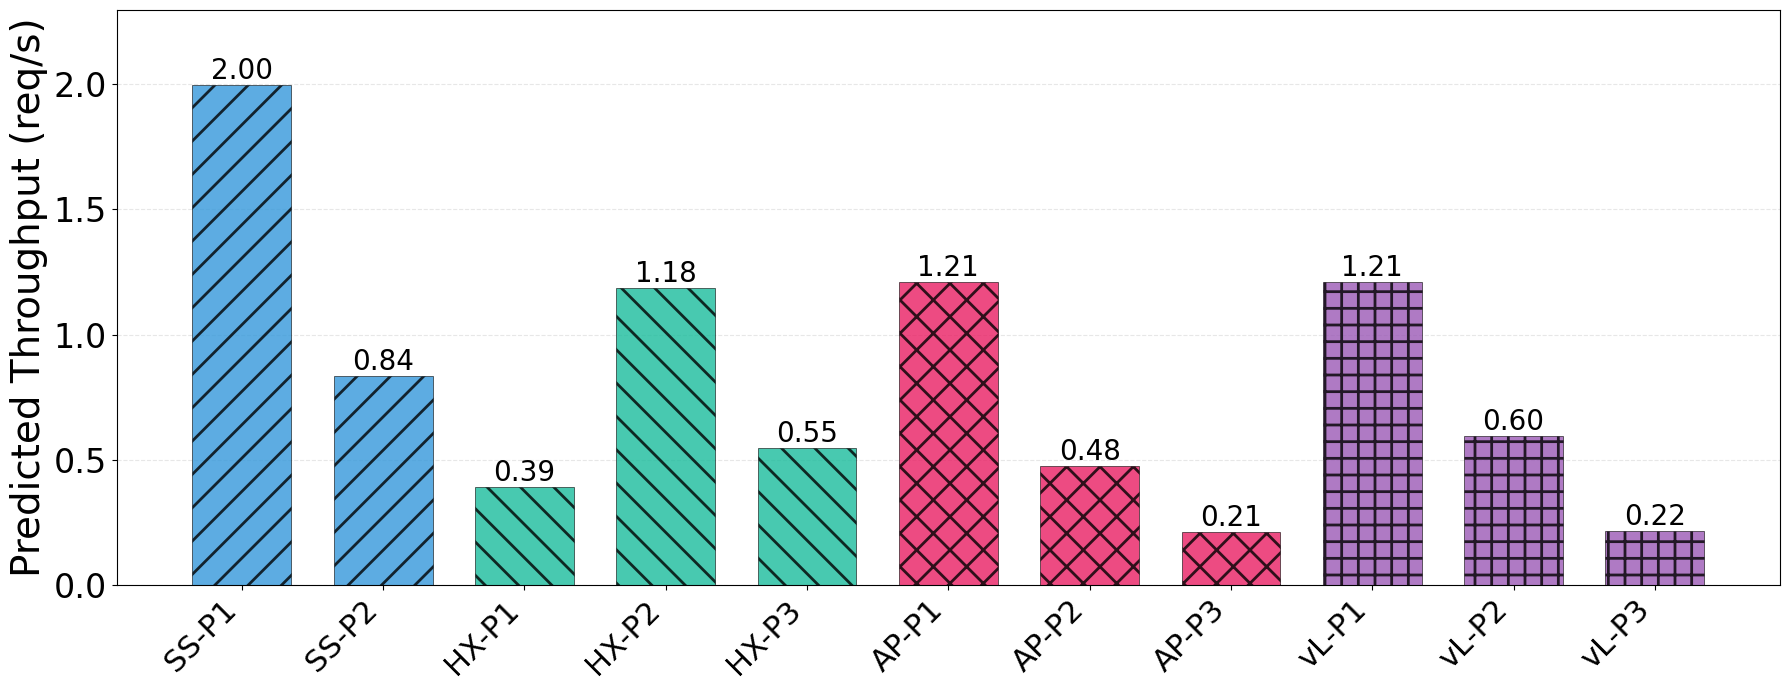

In [4]:
# === Per-Pipeline Bar Plot (Predicted only, or Predicted vs Measured) ===

labels = [p['label'] for p in all_pipelines]
predicted_vals = [p['predicted'] for p in all_pipelines]
systems = [p['system'] for p in all_pipelines]

x = np.arange(len(labels))

if has_measured:
    # Grouped bar: predicted vs measured
    measured_vals = [measured_map.get(l, 0) for l in labels]
    bar_width = 0.35
    fig, ax = plt.subplots(figsize=(20, 8))
    
    for i, (lbl, pred, meas, sys) in enumerate(zip(labels, predicted_vals, measured_vals, systems)):
        style = SYSTEM_STYLE[sys]
        # Predicted bar
        ax.bar(x[i] - bar_width/2, pred, bar_width, 
               color=style['color'], alpha=0.8, edgecolor='black', linewidth=0.5,
               hatch=style['hatch'])
        # Measured bar (solid, no hatch)
        if meas and meas > 0:
            ax.bar(x[i] + bar_width/2, meas, bar_width,
                   color=style['color'], alpha=0.5, edgecolor='black', linewidth=0.5)
    
    ax.set_ylabel('Throughput (req/s)', fontsize=FONTSIZE)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=FONTSIZE - 6, rotation=45, ha='right')
    ax.tick_params(axis='y', labelsize=FONTSIZE - 4)
    ax.set_ylim(0, max(max(predicted_vals), max(measured_vals)) * 1.15)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Add value labels
    for i, (pred, meas) in enumerate(zip(predicted_vals, measured_vals)):
        ax.text(x[i] - bar_width/2, pred, f'{pred:.2f}', ha='center', va='bottom', fontsize=FONTSIZE - 10)
        if meas and meas > 0:
            ax.text(x[i] + bar_width/2, meas, f'{meas:.2f}', ha='center', va='bottom', fontsize=FONTSIZE - 10)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'llama3-70b_pipeline_throughput_predicted_vs_measured.pdf'), format='pdf', bbox_inches='tight')
    plt.show()

else:
    # Predicted only
    fig, ax = plt.subplots(figsize=(18, 7))
    
    for i, (lbl, val, sys) in enumerate(zip(labels, predicted_vals, systems)):
        style = SYSTEM_STYLE[sys]
        ax.bar(x[i], val, 0.7,
               color=style['color'], alpha=0.8, edgecolor='black', linewidth=0.5,
               hatch=style['hatch'])
    
    ax.set_ylabel('Predicted Throughput (req/s)', fontsize=FONTSIZE)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=FONTSIZE - 6, rotation=45, ha='right')
    ax.tick_params(axis='y', labelsize=FONTSIZE - 4)
    ax.set_ylim(0, max(predicted_vals) * 1.15)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Add value labels
    for i, val in enumerate(predicted_vals):
        ax.text(x[i], val, f'{val:.2f}', ha='center', va='bottom', fontsize=FONTSIZE - 8)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'llama3-70b_pipeline_throughput_predicted.pdf'), format='pdf', bbox_inches='tight')
    plt.show()


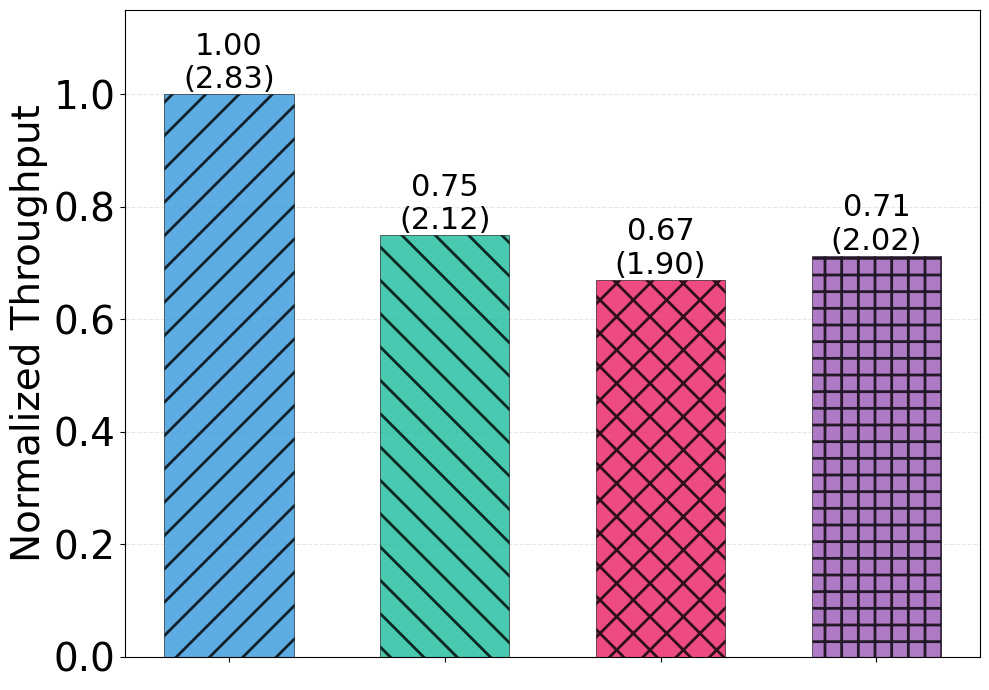

In [5]:
# === System-Level Total Throughput (Normalized by ShuntServe) ===

system_order_plot = ['ShuntServe', 'HexGen', 'AlpaServe', 'vLLM']
totals = [system_totals.get(s, 0) for s in system_order_plot]
shuntserve_total = system_totals.get('ShuntServe', 1)
normalized = [t / shuntserve_total for t in totals]

fig, ax = plt.subplots(figsize=(10, 7))

for i, sys in enumerate(system_order_plot):
    style = SYSTEM_STYLE[sys]
    ax.bar(i, normalized[i], 0.6,
           color=style['color'], alpha=0.8, edgecolor='black', linewidth=0.5,
           hatch=style['hatch'])

ax.set_ylabel('Normalized Throughput', fontsize=FONTSIZE)
ax.set_xticks(range(len(system_order_plot)))
ax.set_xticklabels([])
ax.tick_params(axis='y', labelsize=FONTSIZE)
ax.set_ylim(0, max(normalized) * 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add value labels
for i, (val, raw) in enumerate(zip(normalized, totals)):
    ax.text(i, val, f'{val:.2f}\n({raw:.2f})',
            ha='center', va='bottom', fontsize=FONTSIZE - 6)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'llama3-70b_system_throughput_normalized.pdf'), format='pdf', bbox_inches='tight')
plt.show()


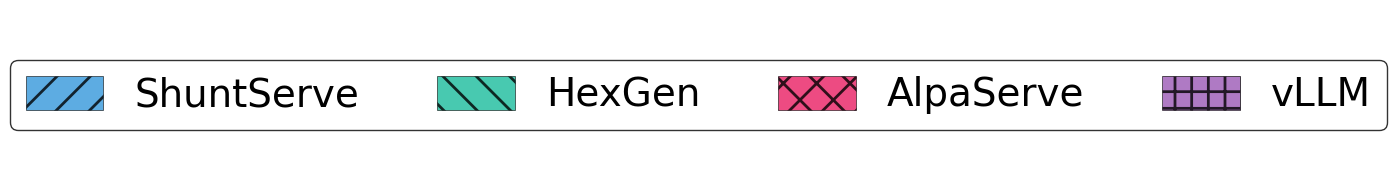

In [6]:
# === Legend (separate, for composing in paper) ===

fig, ax = plt.subplots(figsize=(12, 2))
ax.axis('off')

legend_patches = [
    mpatches.Patch(
        facecolor=SYSTEM_STYLE[s]['color'], label=s, alpha=0.8,
        edgecolor='black', linewidth=0.5, hatch=SYSTEM_STYLE[s]['hatch']
    )
    for s in system_order_plot
]

if has_measured:
    legend_patches.extend([
        mpatches.Patch(facecolor='white', edgecolor='black', linewidth=0.5,
                       hatch='///', label='Predicted', alpha=0.8),
        mpatches.Patch(facecolor='gray', edgecolor='black', linewidth=0.5,
                       label='Measured', alpha=0.5),
    ])

ax.legend(handles=legend_patches, loc='center',
          ncol=len(legend_patches), fontsize=FONTSIZE,
          frameon=True, handlelength=2, handleheight=1, edgecolor='black')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'llama3-70b_throughput_legend.pdf'), format='pdf', bbox_inches='tight')
plt.show()


---

# Qwen3-32B


In [7]:
RESULTS_DIR = os.path.join(BASE_DIR, 'qwen3-32b')
FIG_DIR = os.path.join(BASE_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)
print(f'Results dir: {os.path.abspath(RESULTS_DIR)}')


Results dir: /home/ubuntu/ShuntServe/ArtifactEvaluation/ReferenceData/ModelPlacement/per-pipeline/qwen3-32b


In [8]:
# Load all predicted results
predicted_files = sorted(glob.glob(os.path.join(RESULTS_DIR, 'predicted_*.json')))

all_pipelines = []  # list of {label, system, predicted_throughput_rps}
system_totals = {}  # system -> total throughput

for fpath in predicted_files:
    with open(fpath) as f:
        data = json.load(f)
    for p in data['pipelines']:
        entry = {
            'label': p['label'],
            'system': p['system'],
            'predicted': p['predicted_throughput_rps'],
        }
        all_pipelines.append(entry)
        system_totals[p['system']] = system_totals.get(p['system'], 0) + p['predicted_throughput_rps']

# Sort pipelines by system order, then pipeline label
system_order = ['ShuntServe', 'HexGen', 'AlpaServe', 'vLLM']
all_pipelines.sort(key=lambda x: (system_order.index(x['system']), x['label']))

print(f'Loaded {len(all_pipelines)} pipelines from {len(predicted_files)} files')
for p in all_pipelines:
    print(f"  {p['label']:8s} ({p['system']:12s}): {p['predicted']:.4f} req/s")
print()
for sys in system_order:
    print(f"  {sys:12s} total: {system_totals.get(sys, 0):.4f} req/s")


Loaded 20 pipelines from 4 files
  SS-P1    (ShuntServe  ): 8.6324 req/s
  SS-P2    (ShuntServe  ): 2.9091 req/s
  SS-P3    (ShuntServe  ): 0.5046 req/s
  SS-P4    (ShuntServe  ): 0.5046 req/s
  HX-P1    (HexGen      ): 1.9415 req/s
  HX-P2    (HexGen      ): 1.7482 req/s
  HX-P3    (HexGen      ): 2.5169 req/s
  HX-P4    (HexGen      ): 1.6298 req/s
  HX-P5    (HexGen      ): 1.5075 req/s
  HX-P6    (HexGen      ): 1.9415 req/s
  AP-P1    (AlpaServe   ): 0.7198 req/s
  AP-P2    (AlpaServe   ): 0.7198 req/s
  AP-P3    (AlpaServe   ): 0.7198 req/s
  AP-P4    (AlpaServe   ): 0.8967 req/s
  AP-P5    (AlpaServe   ): 0.8967 req/s
  AP-P6    (AlpaServe   ): 1.3420 req/s
  AP-P7    (AlpaServe   ): 1.3420 req/s
  vL-P1    (vLLM        ): 2.2384 req/s
  vL-P2    (vLLM        ): 1.8003 req/s
  vL-P3    (vLLM        ): 6.1602 req/s

  ShuntServe   total: 12.5507 req/s
  HexGen       total: 11.2855 req/s
  AlpaServe    total: 6.6368 req/s
  vLLM         total: 10.1989 req/s


In [9]:
# Load measured results (if available)
measured_files = sorted(glob.glob(os.path.join(RESULTS_DIR, 'measured_*.json')))

measured_map = {}  # label -> throughput
for fpath in measured_files:
    with open(fpath) as f:
        data = json.load(f)
    # Expected format: {"label": "SS-P1", "measured_throughput_rps": ...}
    # or pipeline_ranking benchmark output format
    if 'pipelines' in data:
        for p in data['pipelines']:
            measured_map[p['label']] = p.get('measured_throughput_rps', None)
    elif 'label' in data:
        measured_map[data['label']] = data.get('measured_throughput_rps', 
                                               data.get('throughput', None))

has_measured = len(measured_map) > 0
print(f'Measured data: {len(measured_map)} pipelines' if has_measured else 'No measured data yet')


No measured data yet


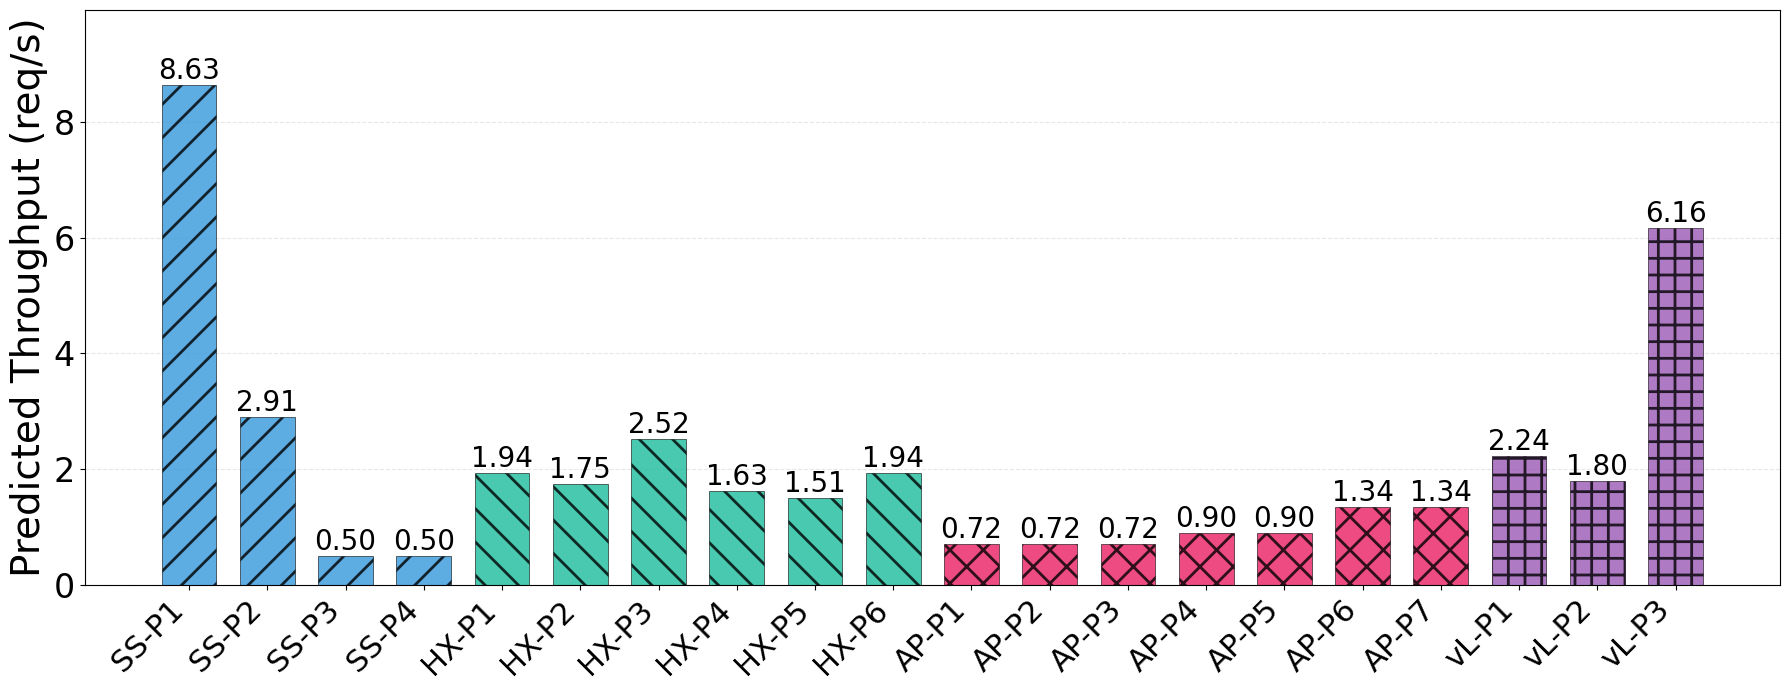

In [10]:
# === Per-Pipeline Bar Plot (Predicted only, or Predicted vs Measured) ===

labels = [p['label'] for p in all_pipelines]
predicted_vals = [p['predicted'] for p in all_pipelines]
systems = [p['system'] for p in all_pipelines]

x = np.arange(len(labels))

if has_measured:
    # Grouped bar: predicted vs measured
    measured_vals = [measured_map.get(l, 0) for l in labels]
    bar_width = 0.35
    fig, ax = plt.subplots(figsize=(20, 8))
    
    for i, (lbl, pred, meas, sys) in enumerate(zip(labels, predicted_vals, measured_vals, systems)):
        style = SYSTEM_STYLE[sys]
        # Predicted bar
        ax.bar(x[i] - bar_width/2, pred, bar_width, 
               color=style['color'], alpha=0.8, edgecolor='black', linewidth=0.5,
               hatch=style['hatch'])
        # Measured bar (solid, no hatch)
        if meas and meas > 0:
            ax.bar(x[i] + bar_width/2, meas, bar_width,
                   color=style['color'], alpha=0.5, edgecolor='black', linewidth=0.5)
    
    ax.set_ylabel('Throughput (req/s)', fontsize=FONTSIZE)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=FONTSIZE - 6, rotation=45, ha='right')
    ax.tick_params(axis='y', labelsize=FONTSIZE - 4)
    ax.set_ylim(0, max(max(predicted_vals), max(measured_vals)) * 1.15)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Add value labels
    for i, (pred, meas) in enumerate(zip(predicted_vals, measured_vals)):
        ax.text(x[i] - bar_width/2, pred, f'{pred:.2f}', ha='center', va='bottom', fontsize=FONTSIZE - 10)
        if meas and meas > 0:
            ax.text(x[i] + bar_width/2, meas, f'{meas:.2f}', ha='center', va='bottom', fontsize=FONTSIZE - 10)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'qwen3-32b_pipeline_throughput_predicted_vs_measured.pdf'), format='pdf', bbox_inches='tight')
    plt.show()

else:
    # Predicted only
    fig, ax = plt.subplots(figsize=(18, 7))
    
    for i, (lbl, val, sys) in enumerate(zip(labels, predicted_vals, systems)):
        style = SYSTEM_STYLE[sys]
        ax.bar(x[i], val, 0.7,
               color=style['color'], alpha=0.8, edgecolor='black', linewidth=0.5,
               hatch=style['hatch'])
    
    ax.set_ylabel('Predicted Throughput (req/s)', fontsize=FONTSIZE)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=FONTSIZE - 6, rotation=45, ha='right')
    ax.tick_params(axis='y', labelsize=FONTSIZE - 4)
    ax.set_ylim(0, max(predicted_vals) * 1.15)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Add value labels
    for i, val in enumerate(predicted_vals):
        ax.text(x[i], val, f'{val:.2f}', ha='center', va='bottom', fontsize=FONTSIZE - 8)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'qwen3-32b_pipeline_throughput_predicted.pdf'), format='pdf', bbox_inches='tight')
    plt.show()


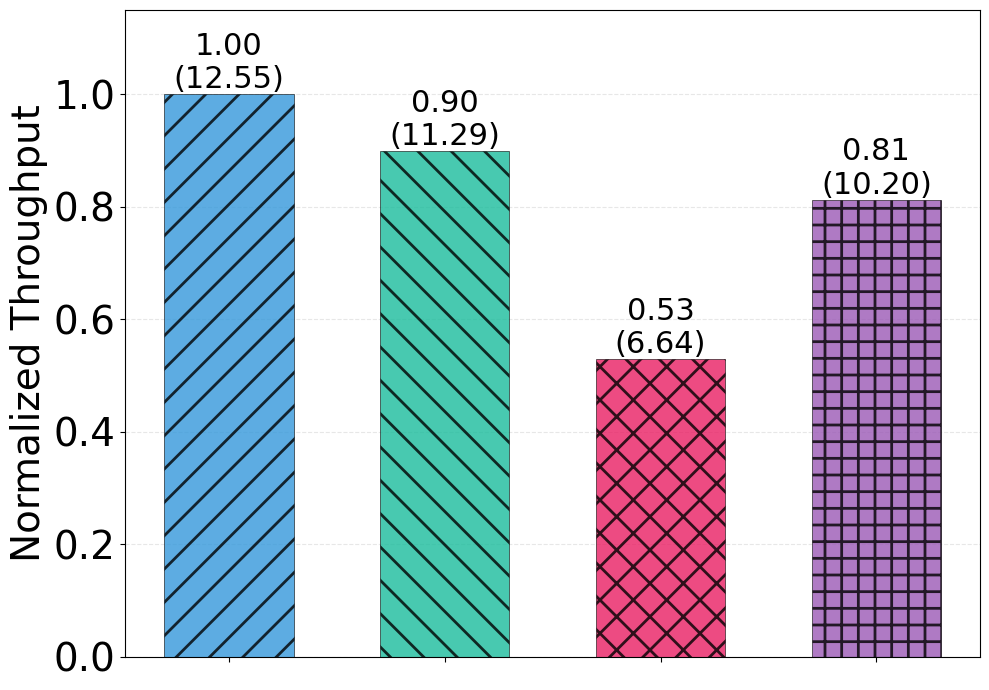

In [11]:
# === System-Level Total Throughput (Normalized by ShuntServe) ===

system_order_plot = ['ShuntServe', 'HexGen', 'AlpaServe', 'vLLM']
totals = [system_totals.get(s, 0) for s in system_order_plot]
shuntserve_total = system_totals.get('ShuntServe', 1)
normalized = [t / shuntserve_total for t in totals]

fig, ax = plt.subplots(figsize=(10, 7))

for i, sys in enumerate(system_order_plot):
    style = SYSTEM_STYLE[sys]
    ax.bar(i, normalized[i], 0.6,
           color=style['color'], alpha=0.8, edgecolor='black', linewidth=0.5,
           hatch=style['hatch'])

ax.set_ylabel('Normalized Throughput', fontsize=FONTSIZE)
ax.set_xticks(range(len(system_order_plot)))
ax.set_xticklabels([])
ax.tick_params(axis='y', labelsize=FONTSIZE)
ax.set_ylim(0, max(normalized) * 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add value labels
for i, (val, raw) in enumerate(zip(normalized, totals)):
    ax.text(i, val, f'{val:.2f}\n({raw:.2f})',
            ha='center', va='bottom', fontsize=FONTSIZE - 6)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'qwen3-32b_system_throughput_normalized.pdf'), format='pdf', bbox_inches='tight')
plt.show()


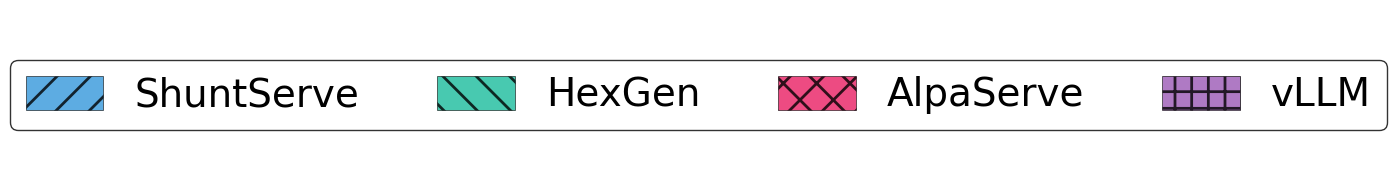

In [12]:
# === Legend (separate, for composing in paper) ===

fig, ax = plt.subplots(figsize=(12, 2))
ax.axis('off')

legend_patches = [
    mpatches.Patch(
        facecolor=SYSTEM_STYLE[s]['color'], label=s, alpha=0.8,
        edgecolor='black', linewidth=0.5, hatch=SYSTEM_STYLE[s]['hatch']
    )
    for s in system_order_plot
]

if has_measured:
    legend_patches.extend([
        mpatches.Patch(facecolor='white', edgecolor='black', linewidth=0.5,
                       hatch='///', label='Predicted', alpha=0.8),
        mpatches.Patch(facecolor='gray', edgecolor='black', linewidth=0.5,
                       label='Measured', alpha=0.5),
    ])

ax.legend(handles=legend_patches, loc='center',
          ncol=len(legend_patches), fontsize=FONTSIZE,
          frameon=True, handlelength=2, handleheight=1, edgecolor='black')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'qwen3-32b_throughput_legend.pdf'), format='pdf', bbox_inches='tight')
plt.show()
